# Assignment 2. Simple Agents

An **agent** is anything that can perceive its environment through sensors, and act upon that environment through actuators based on its **agent program**

Our goal is to design an **agent program (AP)** that implements *the agent function: the mapping from percepts to actions*.

We assume this AP will run on some sort of computing device with physical sensors and actuators: we call this the architecture

An `AP takes the current percept as input from the sensors` and `returns an action` to the actuators.

The AP takes just the current percept as input because nothing more is available from the environment; if the agent's actions depend on the entire percept sequence, the agent will have to remember the percept.

In [1]:
import random
import collections

## Class Thing - for ANY obj in ANY Env

Let's add the class **Thing**  - a base class represents ANY physical object that can appear in ANT Environment

In [2]:
from src.thingClass import Thing

In [3]:
thing0=Thing()
print(thing0)
print(thing0.is_alive())
print(thing0.show_state())

<Thing>
False
I don't know how to show_state.
None


## Class Agent - a base for ANY Agent

Now we need to add the **Agent**  - *subclass of a base Thing* class

It has one required slot (attribute), *.program*, which reperesents *Agent Program* (the Core of Agent's logic).

Agent Program should hold a function that takes one argument, the *Percept*, and returns an *action*.

!!! Note that `.program` is a slot, not a method.

If it were a method, then the program could 'cheat' and look at aspects of the agent.
It's not supposed to do that: the program can only look at the percepts


There is an optional slot, `.performance`, which is a number giving the performance measure of the agent in its environment.


In [4]:
from src.agentClass import Agent

For the easiest example let's implement the `Random Agent Program` to choose an action at random, ignoring all percepts

In [5]:
def RandomAgentProgram(actions):
   return lambda percept: random.choice(actions)

In [6]:
actionList = ['Right', 'Left', 'Suck', 'NoOp']
f=RandomAgentProgram(actionList)
for i in range(5):
    print(f('111'))

NoOp
Left
NoOp
Right
Left


Next, we try to implement the **Random Agent** - the `Agent instance` that randomly choose one of the actions from the vacuum environment (our *actionList*)

In [7]:
def RandomVacuumAgent():
    return Agent(RandomAgentProgram(actionList))

In [8]:
a1=RandomVacuumAgent()
print(f"{a1} has the performance: {a1.performance}")
for i in range(5):
  print(a1.program('111'))

<Agent> has the performance: 0
Left
Left
Suck
Right
NoOp


## Class Environment - a base for ANY Env

Now we need to add the class **Environment** - *a base class* representing a abstract Environment.
* The environment keeps a list of *.agents*.
* Each agent has a *.performance* slot, initialized to 0.

**!!! 'Real' Environment classes must inherit from this one.**

Our **TrivialVacuumEnvironment** has 2 locations, A and B
These are the 2 locations for the 2-state environment.

* Each can be Dirty or Clean. 
* The agent perceives its location and the location's status. 


This serves as an example of how to implement a simple Environment for the further assignment tasks.

How to **track performance**?

* Score +10 for each dirt cleaned; 
* -1 for each move.

In [9]:
from src.trivialVacuumEnvironmentClass import TrivialVacuumEnvironment

In [10]:
e1 = TrivialVacuumEnvironment()
# Check the initial state of the environment
print("State of the Environment: {}.".format(e1.status))

State of the Environment: {(0, 0): 'Clean', (0, 1): 'Clean'}.


## Random Agent Template

Create our Random Agent now.

This agent will choose any of the actions from 'Right', 'Left', 'Suck' and 'NoOp' (No Operation) randomly.

In [11]:
a1=RandomVacuumAgent()

Add our agent (a1) to our environment instance (e1).

In [12]:
e1.add_thing(a1)
print("RandomVacuumAgent is located at {}.".format(a1.location))

Agent is starting in random location...
RandomVacuumAgent is located at (0, 1).


Let's run our environment(e1) for 1 step

In [13]:
# Running the environment for 1 step
e1.step()

# Check the current state of the environment
print("State of the Environment: {}.".format(e1.status))

print("RandomVacuumAgent is located at {}.".format(a1.location))

Agent Performance: 0
Agent Agent percepted ((0, 1), 'Clean').
Agent decided to do Left.
Agents: [<Agent>] Actions: ['Left']
Paired: [(<Agent>, 'Left')]
Agent Left
Agent <Agent> is dead.
State of the Environment: {(0, 0): 'Clean', (0, 1): 'Clean'}.
RandomVacuumAgent is located at (0, 0).


Let's try running the environment for the lifecircle

In [14]:
e1.run()

loc: (0, 0), perf: -1
We can't find a live agent


In [15]:
e1.status == {(1,0):'Clean' , (0,0) : 'Clean'}

False

In [16]:
#prev.version of our random agent is almost immortal :))
a1.performance

-1

In [17]:
a1.location

(0, 0)

In [18]:
e2=TrivialVacuumEnvironment()
a2=RandomVacuumAgent()

e2.add_thing(a2)

print("State of the Environment: {}.".format(e2.status))
print("RandomVacuumAgent is located at {}.".format(a2.location))

Agent is starting in random location...
State of the Environment: {(0, 0): 'Clean', (0, 1): 'Dirty'}.
RandomVacuumAgent is located at (0, 0).


In [19]:
e2.run()

loc: (0, 0), perf: 0
step 1:
Agent Performance: 0
Agent Agent percepted ((0, 0), 'Clean').
Agent decided to do Left.
Agents: [<Agent>] Actions: ['Left']
Paired: [(<Agent>, 'Left')]
Agent Left
Agent <Agent> is dead.
loc: (0, 0), perf: -1
We can't find a live agent


## Simple Reflex agents

These agents *select actions on the basis of the **current** percept, ignoring the rest of the percept history*.

These agents work on a **condition-action rule** (also called situation-action rule, production or if-then rule), which *tells the agent the action to trigger when a particular situation is encountered*.

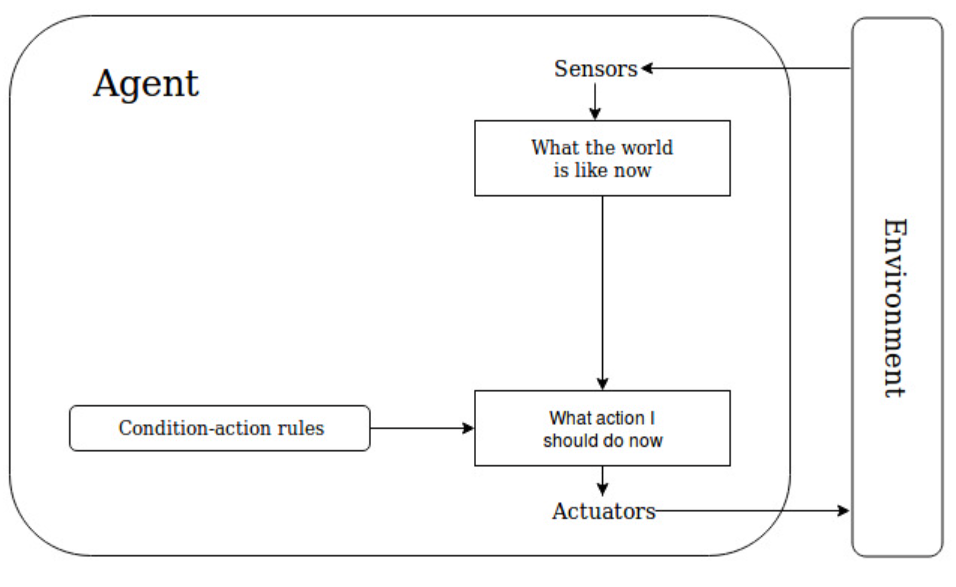

A general and flexible approach is `first to build a general-purpose interpreter` for condition–action rules and `then to create rule sets` for specific task environments

The structure of this general program in schematic form --> below, showing how the condition–action rules allow the agent to make the connection from percept to action:

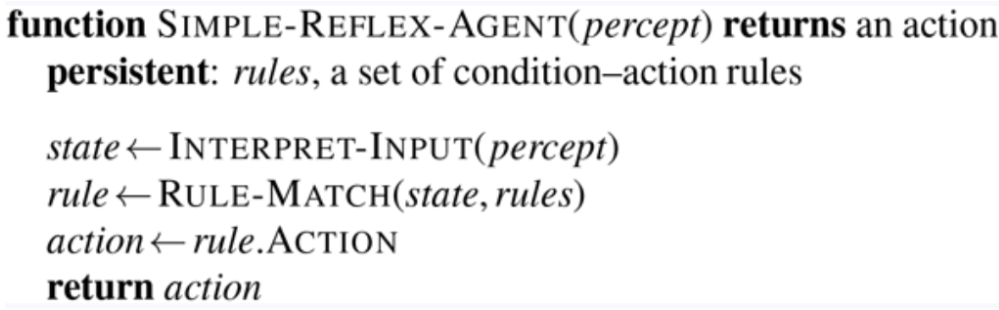

In [20]:
def SimpleReflexAgentProgram(rules, interpret_input):
    #This AP takes action based solely on the percept.

    def program(percept):
        state = interpret_input(percept)
        rule = rule_match(state, rules)
        action = rule.action
        return action

    return program

def rule_match(state, rules):
  for key in rules:
    if state in key:
      return rules[key]
    
def interpret_input(percept):
  loc, status = percept
  return status

If condition–action rules stored as a Python Dictionary

`rules={((0, 0), 'Dirty'): 'Suck',
        (((1, 0), 'Dirty'): 'Suck',
        (((0, 0), 'Clean'): 'Right',
        (((1, 0), 'Clean'): 'Left',
        }`



### Vacuum Reflex Agent (for 2-location vacuum environment) example

The agent program for a simple reflex agent in the two-location vacuum environment.

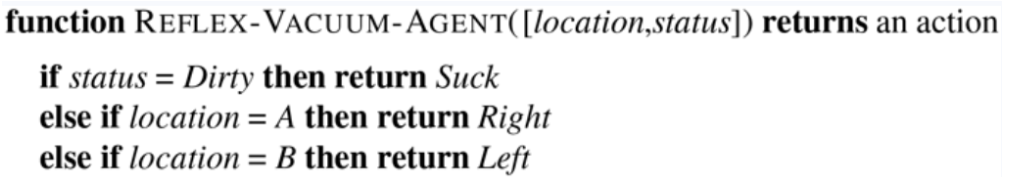

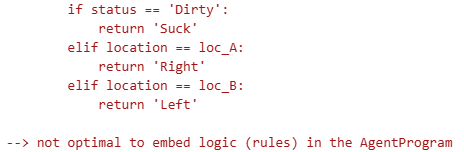

In [21]:
# These are the two locations for the two-state environme
from src.locations import *

print(loc_A, loc_B)

(0, 0) (0, 1)


In [22]:
rules={((0, 0), 'Dirty'): 'Suck', ((1, 0), 'Dirty'): 'Suck', ((0, 0), 'Clean'): 'Right',((1, 0), 'Clean'): 'Left'}
rules

{((0, 0), 'Dirty'): 'Suck',
 ((1, 0), 'Dirty'): 'Suck',
 ((0, 0), 'Clean'): 'Right',
 ((1, 0), 'Clean'): 'Left'}

In [23]:
percept=(loc_A,'Dirty')
percept

((0, 0), 'Dirty')

In [24]:
state=interpret_input(percept)
state

'Dirty'

In [25]:
rule_match(state, rules)

'Suck'

In [26]:
#let's check if (how) we can work with locations
locations=loc_A, loc_B
(1,0) in locations

False

In [27]:
a=loc_A
print(a)
print(locations.index(a))
print(f"Loc.B: {locations[locations.index(a)+1]}")

(0, 0)
0
Loc.B: (0, 1)


Let's create our **Vacuum Reflex Agent** based on *SimpleReflexAgentProgram* as AP and rules stored as a dictionary (vacuumRules)

In [28]:
from src.agents import ReflexAgent

In [29]:
VRA1=ReflexAgent()

Next, we need to check it - if the AP works correctly (if the correct action is being selected based on the precept)

In [30]:
loc_A, loc_B

((0, 0), (0, 1))

In [31]:
testPercept1=(loc_A,'Dirty')
VRA1.program(testPercept1)

'Suck'

Let's create the new instance of the Vacuum Env.

In [32]:
e1_test=TrivialVacuumEnvironment()
print("State of the Environment: {}.".format(e1_test.status))


State of the Environment: {(0, 0): 'Dirty', (0, 1): 'Clean'}.


Then, we are placing our new RA  instance (RV1) into our environment (new instance - e4)

In [33]:
e1_test.add_thing(VRA1)
print("ReflexVacuumAgent is located at {}.".format(VRA1.location))

Agent is starting in random location...
ReflexVacuumAgent is located at (0, 1).


In [34]:
e1_test.step()

Agent Performance: 0
Agent Agent percepted ((0, 1), 'Clean').
Agent decided to do Right.
Agents: [<Agent>] Actions: ['Right']
Paired: [(<Agent>, 'Right')]
Agent Right
Agent <Agent> is dead.


['Right']

In [35]:
print("State of the Environment: {}.".format(e1_test.status))

State of the Environment: {(0, 0): 'Dirty', (0, 1): 'Clean'}.


In [36]:
print("ReflexVacuumAgent is located at {}.".format(VRA1.location))

ReflexVacuumAgent is located at (0, 1).


In [37]:
e1_test.step()

There is no one here who could work...


[]

In [38]:
print("State of the Environment: {}.".format(e1_test.status))

State of the Environment: {(0, 0): 'Dirty', (0, 1): 'Clean'}.


In [39]:
print("ReflexVacuumAgent is located at {}.".format(VRA1.location))

ReflexVacuumAgent is located at (0, 1).


In [40]:
e1_test.step()

There is no one here who could work...


[]

In [41]:
print("State of the Environment: {}.".format(e1_test.status))

State of the Environment: {(0, 0): 'Dirty', (0, 1): 'Clean'}.


But!!! it will stop only..... Let's find out ...

In [42]:
e1_test.run() #Run the Environment for given number of time steps

loc: (0, 1), perf: -1
We can't find a live agent


This must be improved by using the concept of Performance.

## Tasks

### Task-1: Reflex Delivery Agent

There is an office building with 4 rooms.

In [43]:
from src.locations import *

In [44]:
locations=loc_A, loc_B, loc_C, loc_D
locations

((0, 0), (0, 1), (1, 0), (1, 1))

To create this environment we need to develop 2 new classes:
* `environmentPro` (derived form *Environment* class)  
* `CompanyEnvironment` (derived from *environmentPro*)

**Explore details of both new classes**!!! BEFORE the next step


The delivery agent moves from one room to another and gives the package according to the type of recipient in the room.
The recipients are:
* an office manager - waiting for daily mail
* an IT specialist - ordered donuts from Tim Hortons
* a Student - ordered a pizza from Domino Pizza

**!!! You need to develop their classes (derived from Thing class)** ->> complete the code in the `Task1_YourRecipientsClasses.py`


The initial distribution recipients among 4 rooms is random and unknown to the Agent.


However, the Agent can perceive its location (what room is current) and all recipients in the room.
The Agent Program is able to recognize the type of recipient based on the Agent's percepts (one recipient per step) -> check `interpret_input_A2pro` function (in the `agentprograms.py`)

**Create your Agent** (comleete the `ReflexAgentA2pro` function in the `agents.py`)


The Agent gives the suitable package to the recipient.

If all recipients in the room have already received their packages (or nobody in the room) the Agent moves to the next room.

When the last room has been checked the Agent stops.
The initial position of the Agent is random.

Let's try your code!

In [45]:
from src.CompanyEnvironmentClass import CompanyEnvironment

Create the instanse of your Company Environment

In [46]:

ce=CompanyEnvironment()

In [47]:
from src.Task1_YourRecipientsClasses import OfficeManager,Student,ITStaff

Create your recipient and accomodate them.

In [48]:
s=Student()
i=ITStaff()
o=OfficeManager()

I am Student Hanna
I am ITStaff Jack
I am OfficeManager Joe


In [49]:
ce.add_thing(i)
print("IT is located at {}.".format(i.location))

ce.add_thing(s)
print("Student is located at {}.".format(s.location))

ce.add_thing(o)
print("OfficeManager is located at {}.".format(o.location))

The item is starting in random location...
IT is located at (1, 1).
The item is starting in random location...
Student is located at (1, 0).
The item is starting in random location...
OfficeManager is located at (1, 0).


In [50]:
for t in ce.things:
    print(f"Hi, I am {t.name}: {type(t)} at {t.location}")

Hi, I am Jack: <class 'src.Task1_YourRecipientsClasses.ITStaff'> at (1, 1)
Hi, I am Hanna: <class 'src.Task1_YourRecipientsClasses.Student'> at (1, 0)
Hi, I am Joe: <class 'src.Task1_YourRecipientsClasses.OfficeManager'> at (1, 0)


In [51]:
from src.agents import ReflexAgentA2pro

In [52]:
raTask1pro1=ReflexAgentA2pro()

In [53]:
ce.add_thing(raTask1pro1)

The item is starting in random location...
Welcome! You are added in location (0, 1)


In [54]:
print("State of the Office Environment: {}.".format(ce.locations))
print("Delivery Agent is located at {}.".format(raTask1pro1.location))

State of the Office Environment: [(0, 0), (0, 1), (1, 0), (1, 1)].
Delivery Agent is located at (0, 1).


In [55]:
ce.step()

Agent Performance: 0
Clear
Agent Agent percepted ((0, 1), []).
Agent decided to do Go ahead.
Agents: [<Agent>] Actions: ['Go ahead']
Paired: [(<Agent>, 'Go ahead')]
Agent Go ahead
Agent <Agent> is dead.
The Agent decided to Go ahead at location: (1, 0)


['Go ahead']

In [72]:
ce.run()

loc: (1, 0), perf: -1
We can't find a live agent


### Task-2: Reflex Cat-Agent

1. Implement the environment - **Cat-Friendly-House** - has 3 rooms in a row.

In [57]:
from src.catFriendlyHouse_envClass import catFriendlyHouse_env

In [58]:
e=catFriendlyHouse_env()

2. Implement the ```class Food ``` (derived from the baseclass Thing)to store weight, calories, energy. 

And 3 derived classes: Milk, Sausage, and Mouse. 

Mouse has a size and its energy = size*1000.

In [59]:
from src.catFriendlyHouse_membersClass import Milk, Sausage, Mouse

In [60]:
milk=Milk(weight=200,calories=50)
sausage=Sausage(weight=150,calories=505)
mouse=Mouse(size=2)

3. Place a one instance of Milk and a one of instance of Sausage in random room. Repeat the step for a instance of Mouse.

In [ ]:
e.add_thing(milk)
milk.sayHi()
print("I am at {}.".format(milk.location))

e.add_thing(sausage)
sausage.sayHi()
print("I am at {}.".format(sausage.location))

e.add_thing(mouse)
mouse.sayHi()
print("I am at {}.".format(mouse.location))

The item is starting in random location...
There is a milk
I am at (0, 1).
The item is starting in random location...
There is a sausage
I am at (1, 0).
The item is starting in random location...
There is a Mouse with a power 2000
I am at (0, 0).


4. The status of the environment - unknown. But the *.percept* method of this class should set the state of the room based on the kind of instance located there. And it should return the info about status of the current agen't location as it is in our ```TrivialVacuumEnvironment``` example above. The state of the room can be 'Milk'/'Sausage'/'Mouse' (if it contains any instance of the Food) or the list of such items (if there are more than 1 thing in the room) or 'Empty'.

5. Implemet the class Agent-Cat by using the Agent class. Agent-Cat can eat/catch and drink. And its performance changes depending on weight and calories of the food. It is necessary to check the type of food in order to apply the appropriate method (The Agent-Cat can't drink an instance of Sausage).

In [62]:
from src.agents import ReflexAgentA3pro
raTask2pro2=ReflexAgentA3pro()

6. Place the Agent-Cat in random room.

In [63]:
e.add_thing(raTask2pro2)

The item is starting in random location...
Welcome! You are added in location (0, 0)


In [64]:
print("State of the House Environment: {}.".format(e.locations))
print("Cat Agent is located at {}.".format(raTask2pro2.location))

State of the House Environment: [(0, 0), (0, 1), (1, 0)].
Cat Agent is located at (0, 0).


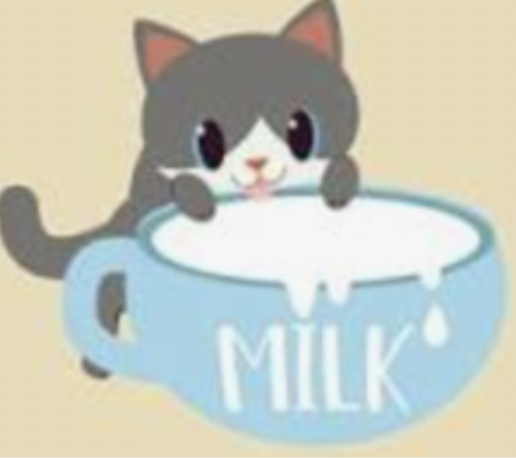

7. Each movement -> perfomace -1
8. Available actions: Drink, Eat, Catch, GoAhead (1 move from Left to Right).

In [65]:
e.run()

loc: (0, 0), perf: 0
step 1:
CatAgent Performance: 0
Loc: (0, 0), status: Mouse
Agent CatAgent percepted ((0, 0), 'Mouse').
Agent decided to do Catch.
Agents: [<CatAgent>] Actions: ['Catch']
Paired: [(<CatAgent>, 'Catch')]
CatAgent Catch
The Cat-Agent is too weak (performance 0) to catch <Mouse>. The Mouse survived and ran away!
Cat performance: 0
loc: (0, 0), perf: 0
step 2:
CatAgent Performance: 0
Loc: (0, 0), status: Empty
Agent CatAgent percepted ((0, 0), 'Empty').
Agent decided to do GoAhead.
Agents: [<CatAgent>] Actions: ['GoAhead']
Paired: [(<CatAgent>, 'GoAhead')]
CatAgent GoAhead
The Agent decided to GoAhead at location: (0, 0)
The Agent moved to (0, 1)
Cat performance: -1
loc: (0, 1), perf: -1
step 3:
CatAgent Performance: -1
Loc: (0, 1), status: Milk
Agent CatAgent percepted ((0, 1), 'Milk').
Agent decided to do Drink.
Agents: [<CatAgent>] Actions: ['Drink']
Paired: [(<CatAgent>, 'Drink')]
CatAgent Drink
The Agent decided to Drink <Milk> at location: (0, 1)
Cat performance: 

9. Improve the logic above to add the following:
* in our case the Mouse is to the left of the Cat-Agent, which is able to move from Left to Right only.
* if the Cat-Agent has already reached the last room and has not consumed ALL items its direction must be updated from Left to Right to Right to Left, and the first room (0,0) will be considered the end of its hunt
* the only case when the Mouse can survive: the Cat-Agent is weak to catch it.

### Task-3: A simple multi-agent environment - Reflex Cat-Agent vs Random Mouse-Agent

1. Implement the advanced version of the environment - **Cat-Friendly-House2** - has 4 rooms in a row.

In [66]:
from src.catFriendlyHouse_envClass import catFriendlyHouse2_env

In [67]:
e2=catFriendlyHouse2_env()

2. Implemet the class ```MouseAgent(Agent)``` and create the RandomMouseAgent agent with a following function:
```python

def RandomMouseAgent():
    return MouseAgent(RandomAgentProgram(mouseAgentLocations))
```


This mouseAgent will choose any of the actions (locations among 4 rooms) randomly.

Each movement -> performance -1

In [68]:
from src.agents import RandomMouseAgent

mouseAgent=RandomMouseAgent()
e2.add_thing(mouseAgent)

print("Mouse Agent is located at {}.".format(mouseAgent.location))

Mouse Agent has a performance 5
The item is starting in random location...
Welcome! You are added in location (0, 1)
Mouse Agent is located at (0, 1).


3. Implemet the ```class proCatAgent(Agent)``` (it has a *direction* prop: True/False, where True: from Left to Right; and *changeDirection()* method - to change its direction to the opposite one).

* Create the instatnce of **ReflexAgent** by using the following function:

```python
def ReflexAgentA4pro():#cat Agent for mouse Agent
    return proCatAgent(ReflexAgentProgram(cat2Rules,interpret_input_A4pro,rule_match))
```


4. Implement the env.class:
```python
#catFriendlyHouse_envClass
class catFriendlyHouse2_env(environmentPro)
```

* This CatAgent can *GoAhead* and *Catch* in the env.

* If the Cat decides to GoAhead, check the direction and if it is the last room (if yes - the direction should change automatically).
* Each movement for a Cat -> perfomace -5
* If the Cat eats a Mouse, the performance will be increased by 10. But to eat a Mouse the Cat must catch it. Only strong Cat can do that. If *Cat's performance < mouse.performance*5*  the Cat is weak and can't catch a Mouse while in the same room with it (but Cat's performance change in this case: performance -= 10).
* If the Cat fights a Dog and wins (only super strong Cat, with performance>=10, can do that) the performance will be increased by 20. Otherwise a Dog wins and a Cat loose its strength (perfomace -10).
* If the Mouse perfomace <=0 it can not move anymore, but still in its last location (available for the Cat)
* If the Cat perfomace <=0 ....GAME OVER!

Run your Crazy House ⚡ 💯 by using the code below.





In [69]:
from src.agents import ReflexAgentA4pro

catAgent=ReflexAgentA4pro()
e2.add_thing(catAgent)


print("Cat Agent is located at {}.".format(catAgent.location))

ProAgent-Cat will move Left to Right with a performance 30
The item is starting in random location...
Welcome! You are added in location (1, 1)
Cat Agent is located at (1, 1).


In [70]:
print("State of the House Environment: {}.".format(e2.locations))
print("N of agents: {}.".format(len(e2.agents)))
for a in e2.agents:
    print(f"loc: {a.location}, perf: {a.performance}")

State of the House Environment: [(0, 0), (0, 1), (1, 0), (1, 1)].
N of agents: 2.
loc: (0, 1), perf: 5
loc: (1, 1), perf: 30


In [71]:
e2.run()
from src.catFriendlyHouse_membersClass import Dog
e3=catFriendlyHouse2_env()
e3.add_thing(RandomMouseAgent())
dog=Dog(); e3.add_thing(dog); dog.sayHi(); print("Dog is at", dog.location)
e3.add_thing(ReflexAgentA4pro())
e3.run(20)

loc: (0, 1), perf: 5
loc: (1, 1), perf: 30
step 1:
MouseAgent Performance: 5
Agent MouseAgent percepted ((0, 1), [], [<MouseAgent>]).
Agent decided to do (0, 1).
proCatAgent Performance: 30
[<proCatAgent>]
Loc: (1, 1), status: Last room
Agent proCatAgent percepted ((1, 1), [], [<proCatAgent>]).
Agent decided to do Check direction.
Agents: [<MouseAgent>, <proCatAgent>] Actions: [(0, 1), 'Check direction']
Paired: [(<MouseAgent>, (0, 1)), (<proCatAgent>, 'Check direction')]
MouseAgent (0, 1)
the Agent Mouse is still running with a performance 5
The Agent Mouse decided to move to (0, 1)
proCatAgent Check direction
Some items are still there ....
The Agent decided to Check direction at location: (1, 1)
ProAgent-Cat will move Right to Left
loc: (0, 1), perf: 4
loc: (1, 0), perf: 25
step 2:
MouseAgent Performance: 4
Agent MouseAgent percepted ((0, 1), [], [<MouseAgent>]).
Agent decided to do (1, 1).
proCatAgent Performance: 25
[<proCatAgent>]
Loc: (1, 0), status: Clear
Agent proCatAgent perc